# Laboratorio 6 — CNN desde cero (CIFAR-10)

## 0. Configuración y datos

In [1]:
import copy
import gc
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"torch {torch.__version__} | device: {device}")
Path("models").mkdir(exist_ok=True)

torch 2.8.0 | device: mps


In [2]:
train_raw = datasets.CIFAR10(root="data", train=True, download=True)
CLASSES = train_raw.classes
y_train = np.array(train_raw.targets)

# Estadísticas por canal del conjunto de entrenamiento completo (escala [0, 1])
X = train_raw.data.astype(np.float64) / 255.0
CIFAR_MEAN, CIFAR_STD = X.mean(axis=(0, 1, 2)), X.std(axis=(0, 1, 2))
del X
print("media:", CIFAR_MEAN.round(4), "| std:", CIFAR_STD.round(4))

# Split 45,000 / 5,000 estratificado (mismo que en el notebook de exploración)
if Path("split_indices.npz").exists():
    s = np.load("split_indices.npz")
    idx_train, idx_val = s["train"], s["val"]
else:
    idx_train, idx_val = train_test_split(
        np.arange(len(y_train)), test_size=5_000, stratify=y_train, random_state=SEED
    )
print(f"train: {len(idx_train):,} | val: {len(idx_val):,}")

# Pipelines (resolución nativa 32x32)
norm = transforms.Normalize(CIFAR_MEAN.tolist(), CIFAR_STD.tolist())
eval_tf = transforms.Compose([transforms.ToTensor(), norm])
train_tf_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    norm,
])

def make_datasets(train_tf):
    full_train = datasets.CIFAR10("data", train=True, download=False, transform=train_tf)
    full_eval = datasets.CIFAR10("data", train=True, download=False, transform=eval_tf)
    return {"train": Subset(full_train, idx_train), "val": Subset(full_eval, idx_val)}

DSETS = {True: make_datasets(train_tf_aug), False: make_datasets(eval_tf)}  # {augment: datasets}

def make_loaders(augment, batch_size):
    # num_workers=0: en macOS (spawn) los workers en notebooks pueden bloquearse
    d = DSETS[augment]
    return (
        DataLoader(d["train"], batch_size=batch_size, shuffle=True, num_workers=0),
        DataLoader(d["val"], batch_size=256, shuffle=False, num_workers=0),
    )

media: [0.4914 0.4822 0.4465] | std: [0.247  0.2435 0.2616]
train: 45,000 | val: 5,000


## 1. Arquitectura

In [3]:
class CNN(nn.Module):
    def __init__(self, channels=(32, 64, 128), conv_dropout=0.0, fc_dropout=0.3,
                 fc_hidden=256, use_bn=True, n_classes=10):
        super().__init__()
        layers, c_in = [], 3
        for c_out in channels:
            for _ in range(2):
                layers.append(nn.Conv2d(c_in, c_out, 3, padding=1, bias=not use_bn))
                if use_bn:
                    layers.append(nn.BatchNorm2d(c_out))
                layers.append(nn.ReLU(inplace=True))
                c_in = c_out
            layers.append(nn.MaxPool2d(2))
            if conv_dropout > 0:
                layers.append(nn.Dropout2d(conv_dropout))
        self.features = nn.Sequential(*layers)
        spatial = 32 // (2 ** len(channels))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c_in * spatial * spatial, fc_hidden),
            nn.BatchNorm1d(fc_hidden) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

print(CNN())
print("params (total, entrenables):", count_params(CNN()))

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1,

## 2. Utilidades de entrenamiento y medición

In [4]:
def sync():
    if device == "cuda": torch.cuda.synchronize()
    elif device == "mps": torch.mps.synchronize()

def mem_now():
    # MPS: driver_allocated_memory incluye el pool de activaciones/gradientes (high-water mark),
    # a diferencia de current_allocated_memory, que solo ve lo vivo en el instante de la llamada.
    if device == "mps": return torch.mps.driver_allocated_memory()
    if device == "cuda": return torch.cuda.memory_allocated()
    return 0

def mem_reset():
    # Libera el pool de corridas anteriores para que el pico de cada iteración sea independiente
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    elif device == "mps":
        torch.mps.empty_cache()

def mem_peak_mb(sampled_peak, baseline):
    if device == "cuda": return torch.cuda.max_memory_allocated() / 2**20
    if device == "mps": return (sampled_peak - baseline) / 2**20
    return float("nan")  # CPU: no se mide

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, preds, labels = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss_sum += criterion(out, y).item() * x.size(0)
        preds.append(out.argmax(1).cpu()); labels.append(y.cpu())
    preds, labels = torch.cat(preds).numpy(), torch.cat(labels).numpy()
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"loss": loss_sum / len(labels), "acc": accuracy_score(labels, preds),
            "precision": p, "recall": r, "f1": f1}

def build_optimizer(model, cfg):
    if cfg["opt"] == "adam":
        return torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    if cfg["opt"] == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    if cfg["opt"] == "sgd":
        return torch.optim.SGD(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"],
                               momentum=0.9, nesterov=True)
    raise ValueError(cfg["opt"])

def run_experiment(name, cfg, verbose=True):
    set_seed()
    mem_reset(); mem_base = mem_now()
    train_loader, val_loader = make_loaders(cfg["augment"], cfg["batch_size"])
    model = CNN(**cfg["model"]).to(device)
    total_p, trainable_p = count_params(model)
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, cfg)
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
                 if cfg["sched"] == "cosine" else None)

    hist = {k: [] for k in ["train_loss", "val_loss", "val_acc", "val_precision",
                            "val_recall", "val_f1", "epoch_time", "cum_time"]}
    best = {"acc": -1.0}
    peak, t_start = mem_base, time.time()

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        sync(); t0 = time.time()
        loss_sum, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            peak = max(peak, mem_now())
            optimizer.step()
            loss_sum += loss.item() * x.size(0); n += x.size(0)
            peak = max(peak, mem_now())
        sync(); epoch_time = time.time() - t0
        if scheduler: scheduler.step()

        m = evaluate(model, val_loader, criterion)
        hist["train_loss"].append(loss_sum / n)
        hist["val_loss"].append(m["loss"])
        hist["val_acc"].append(m["acc"])
        hist["val_precision"].append(m["precision"])
        hist["val_recall"].append(m["recall"])
        hist["val_f1"].append(m["f1"])
        hist["epoch_time"].append(epoch_time)
        hist["cum_time"].append(time.time() - t_start)

        if m["acc"] > best["acc"]:
            best = {**m, "epoch": epoch, "time_to_best": hist["cum_time"][-1],
                    "state": copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})}
        if verbose:
            print(f"[{name}] ep {epoch:02d}/{cfg['epochs']} | train {hist['train_loss'][-1]:.4f} "
                  f"| val {m['loss']:.4f} | acc {m['acc']:.4f} | f1 {m['f1']:.4f} | {epoch_time:.1f}s")

    total_time = time.time() - t_start
    torch.save(best["state"], f"models/cnn_{name}.pt")
    return {
        "name": name, "config": cfg, "history": hist,
        "params_total": total_p, "params_trainable": trainable_p,
        "best_epoch": best["epoch"], "time_to_best": best["time_to_best"],
        "val_best": {k: float(best[k]) for k in ["loss", "acc", "precision", "recall", "f1"]},
        "mean_epoch_time": float(np.mean(hist["epoch_time"])),
        "total_time": total_time, "peak_mem_mb": mem_peak_mb(peak, mem_base),
        "device": device,
    }

## 3. Iteraciones
Cuatro configuraciones, cada una cambia algo respecto a la anterior:

| # | Idea | Qué cambia |
|---|------|-----------|
| 1 | `base` | Línea base: 3 bloques (32-64-128), Adam, dropout sólo en el clasificador |
| 2 | `regularizada` | + dropout espacial, dropout 0.5, AdamW con weight decay y cosine LR |
| 3 | `ancha` | Igual que 2 con el doble de canales (64-128-256) |
| 4 | `sin_augmentation` | Igual que 2 **sin** data augmentation (ablación: mide su efecto sobre el overfitting) |

In [5]:
CONFIGS = {
    "base": dict(
        model=dict(channels=(32, 64, 128), conv_dropout=0.0, fc_dropout=0.3, fc_hidden=256, use_bn=True),
        opt="adam", lr=1e-3, wd=0.0, sched=None, epochs=20, batch_size=128, augment=True),
    "regularizada": dict(
        model=dict(channels=(32, 64, 128), conv_dropout=0.1, fc_dropout=0.5, fc_hidden=256, use_bn=True),
        opt="adamw", lr=2e-3, wd=5e-4, sched="cosine", epochs=30, batch_size=128, augment=True),
    "ancha": dict(
        model=dict(channels=(64, 128, 256), conv_dropout=0.1, fc_dropout=0.5, fc_hidden=256, use_bn=True),
        opt="adamw", lr=2e-3, wd=5e-4, sched="cosine", epochs=25, batch_size=128, augment=True),
    "sin_augmentation": dict(
        model=dict(channels=(32, 64, 128), conv_dropout=0.1, fc_dropout=0.5, fc_hidden=256, use_bn=True),
        opt="adamw", lr=2e-3, wd=5e-4, sched="cosine", epochs=20, batch_size=128, augment=False),
}
RESULTS = {}

### Iteración: `base`

In [6]:
RESULTS["base"] = run_experiment("base", CONFIGS["base"])
r = RESULTS["base"]
print(f"\nMejor epoch: {r['best_epoch']} | val acc {r['val_best']['acc']:.4f} | F1 {r['val_best']['f1']:.4f} "
      f"| tiempo total {r['total_time']:.0f}s | mem pico {r['peak_mem_mb']:.0f} MB")

[base] ep 01/20 | train 1.3028 | val 1.0082 | acc 0.6404 | f1 0.6301 | 10.3s


[base] ep 02/20 | train 0.8917 | val 0.8092 | acc 0.7166 | f1 0.7169 | 9.5s


[base] ep 03/20 | train 0.7484 | val 0.6385 | acc 0.7722 | f1 0.7724 | 9.6s


[base] ep 04/20 | train 0.6530 | val 0.6124 | acc 0.7944 | f1 0.7910 | 10.3s


[base] ep 05/20 | train 0.6062 | val 0.6239 | acc 0.7878 | f1 0.7874 | 9.5s


...

[base] ep 16/20 | train 0.3355 | val 0.3856 | acc 0.8710 | f1 0.8702 | 9.8s


[base] ep 17/20 | train 0.3229 | val 0.4076 | acc 0.8668 | f1 0.8668 | 10.1s


[base] ep 18/20 | train 0.3138 | val 0.3902 | acc 0.8706 | f1 0.8710 | 10.1s


[base] ep 19/20 | train 0.3036 | val 0.4160 | acc 0.8636 | f1 0.8623 | 10.4s


[base] ep 20/20 | train 0.2898 | val 0.3750 | acc 0.8778 | f1 0.8775 | 10.5s

Mejor epoch: 20 | val acc 0.8778 | F1 0.8775 | tiempo total 205s | mem pico 1118 MB


### Iteración: `regularizada`

In [7]:
RESULTS["regularizada"] = run_experiment("regularizada", CONFIGS["regularizada"])
r = RESULTS["regularizada"]
print(f"\nMejor epoch: {r['best_epoch']} | val acc {r['val_best']['acc']:.4f} | F1 {r['val_best']['f1']:.4f} "
      f"| tiempo total {r['total_time']:.0f}s | mem pico {r['peak_mem_mb']:.0f} MB")

[regularizada] ep 01/30 | train 1.5474 | val 1.1569 | acc 0.5818 | f1 0.5772 | 11.8s


[regularizada] ep 02/30 | train 1.1549 | val 0.8527 | acc 0.6888 | f1 0.6831 | 11.7s


[regularizada] ep 03/30 | train 0.9752 | val 0.7360 | acc 0.7384 | f1 0.7369 | 12.4s


[regularizada] ep 04/30 | train 0.8711 | val 0.6694 | acc 0.7628 | f1 0.7631 | 12.0s


[regularizada] ep 05/30 | train 0.8071 | val 0.6236 | acc 0.7832 | f1 0.7839 | 11.8s


...

[regularizada] ep 26/30 | train 0.3550 | val 0.3440 | acc 0.8824 | f1 0.8817 | 14.5s


[regularizada] ep 27/30 | train 0.3494 | val 0.3388 | acc 0.8832 | f1 0.8826 | 13.1s


[regularizada] ep 28/30 | train 0.3472 | val 0.3385 | acc 0.8824 | f1 0.8817 | 12.1s


[regularizada] ep 29/30 | train 0.3435 | val 0.3408 | acc 0.8820 | f1 0.8812 | 12.0s


[regularizada] ep 30/30 | train 0.3423 | val 0.3372 | acc 0.8826 | f1 0.8821 | 12.4s

Mejor epoch: 25 | val acc 0.8832 | F1 0.8827 | tiempo total 383s | mem pico 1098 MB


### Iteración: `ancha`

In [8]:
RESULTS["ancha"] = run_experiment("ancha", CONFIGS["ancha"])
r = RESULTS["ancha"]
print(f"\nMejor epoch: {r['best_epoch']} | val acc {r['val_best']['acc']:.4f} | F1 {r['val_best']['f1']:.4f} "
      f"| tiempo total {r['total_time']:.0f}s | mem pico {r['peak_mem_mb']:.0f} MB")

[ancha] ep 01/25 | train 1.4726 | val 1.0989 | acc 0.6110 | f1 0.6043 | 34.6s


[ancha] ep 02/25 | train 1.0631 | val 0.7698 | acc 0.7292 | f1 0.7248 | 35.5s


[ancha] ep 03/25 | train 0.8812 | val 0.7785 | acc 0.7236 | f1 0.7273 | 34.0s


[ancha] ep 04/25 | train 0.7666 | val 0.6080 | acc 0.7888 | f1 0.7875 | 32.5s


[ancha] ep 05/25 | train 0.6863 | val 0.5200 | acc 0.8184 | f1 0.8188 | 33.9s


...

[ancha] ep 21/25 | train 0.2147 | val 0.2752 | acc 0.9062 | f1 0.9059 | 30.8s


[ancha] ep 22/25 | train 0.2081 | val 0.2765 | acc 0.9046 | f1 0.9044 | 30.6s


[ancha] ep 23/25 | train 0.2026 | val 0.2743 | acc 0.9058 | f1 0.9053 | 30.7s


[ancha] ep 24/25 | train 0.1968 | val 0.2751 | acc 0.9028 | f1 0.9023 | 30.6s


[ancha] ep 25/25 | train 0.1947 | val 0.2744 | acc 0.9052 | f1 0.9048 | 32.5s

Mejor epoch: 21 | val acc 0.9062 | F1 0.9059 | tiempo total 847s | mem pico 1115 MB


### Iteración: `sin_augmentation`

In [9]:
RESULTS["sin_augmentation"] = run_experiment("sin_augmentation", CONFIGS["sin_augmentation"])
r = RESULTS["sin_augmentation"]
print(f"\nMejor epoch: {r['best_epoch']} | val acc {r['val_best']['acc']:.4f} | F1 {r['val_best']['f1']:.4f} "
      f"| tiempo total {r['total_time']:.0f}s | mem pico {r['peak_mem_mb']:.0f} MB")

[sin_augmentation] ep 01/20 | train 1.3523 | val 1.0628 | acc 0.6138 | f1 0.6102 | 13.8s


[sin_augmentation] ep 02/20 | train 0.9357 | val 0.7495 | acc 0.7298 | f1 0.7314 | 11.5s


[sin_augmentation] ep 03/20 | train 0.7755 | val 0.6519 | acc 0.7676 | f1 0.7680 | 11.4s


[sin_augmentation] ep 04/20 | train 0.6742 | val 0.6069 | acc 0.7900 | f1 0.7890 | 11.7s


[sin_augmentation] ep 05/20 | train 0.5994 | val 0.5539 | acc 0.8072 | f1 0.8061 | 12.0s


...

[sin_augmentation] ep 16/20 | train 0.1188 | val 0.5382 | acc 0.8494 | f1 0.8496 | 11.4s


[sin_augmentation] ep 17/20 | train 0.1033 | val 0.5561 | acc 0.8458 | f1 0.8462 | 11.5s


[sin_augmentation] ep 18/20 | train 0.0929 | val 0.5673 | acc 0.8462 | f1 0.8463 | 11.4s


[sin_augmentation] ep 19/20 | train 0.0878 | val 0.5514 | acc 0.8498 | f1 0.8500 | 11.5s


[sin_augmentation] ep 20/20 | train 0.0858 | val 0.5552 | acc 0.8486 | f1 0.8484 | 11.4s

Mejor epoch: 19 | val acc 0.8498 | F1 0.8500 | tiempo total 245s | mem pico 1072 MB


## 4. Resultados de las iteraciones

In [10]:
def frozen_desc(cfg):
    return "n/a (todas las capas se entrenan)"  # CNN desde cero: nada congelado

rows = []
for name, r in RESULTS.items():
    c, m = r["config"], r["config"]["model"]
    rows.append({
        "iteración": name,
        "canales": "-".join(map(str, m["channels"])),
        "dropout conv/fc": f"{m['conv_dropout']}/{m['fc_dropout']}",
        "optimizador": f"{c['opt']} lr={c['lr']} wd={c['wd']}",
        "scheduler": c["sched"] or "-",
        "batch": c["batch_size"],
        "augment": c["augment"],
        "epochs": c["epochs"],
        "capas congeladas": frozen_desc(c),
        "params totales": r["params_total"],
        "params entrenables": r["params_trainable"],
        "mejor epoch": r["best_epoch"],
        "val loss": r["val_best"]["loss"],
        "val acc": r["val_best"]["acc"],
        "val precision": r["val_best"]["precision"],
        "val recall": r["val_best"]["recall"],
        "val F1": r["val_best"]["f1"],
        "s/epoch (media)": r["mean_epoch_time"],
        "tiempo total (s)": r["total_time"],
        "mem pico (MB)": r["peak_mem_mb"],
    })
df = pd.DataFrame(rows).set_index("iteración")
pd.set_option("display.max_columns", None, "display.width", 250)
display(df.T)
print("Dispositivo:", device)

iteración,base,regularizada,ancha,sin_augmentation
canales,32-64-128,32-64-128,64-128-256,32-64-128
dropout conv/fc,0.0/0.3,0.1/0.5,0.1/0.5,0.1/0.5
optimizador,adam lr=0.001 wd=0.0,adamw lr=0.002 wd=0.0005,adamw lr=0.002 wd=0.0005,adamw lr=0.002 wd=0.0005
scheduler,-,cosine,cosine,cosine
batch,128,128,128,128
augment,True,True,True,False
epochs,20,30,25,20
capas congeladas,n/a (todas las capas se entrenan),n/a (todas las capas se entrenan),n/a (todas las capas se entrenan),n/a (todas las capas se entrenan)
params totales,815082,815082,2198218,815082
params entrenables,815082,815082,2198218,815082


Dispositivo: mps


### Curvas de loss (train vs. validación)

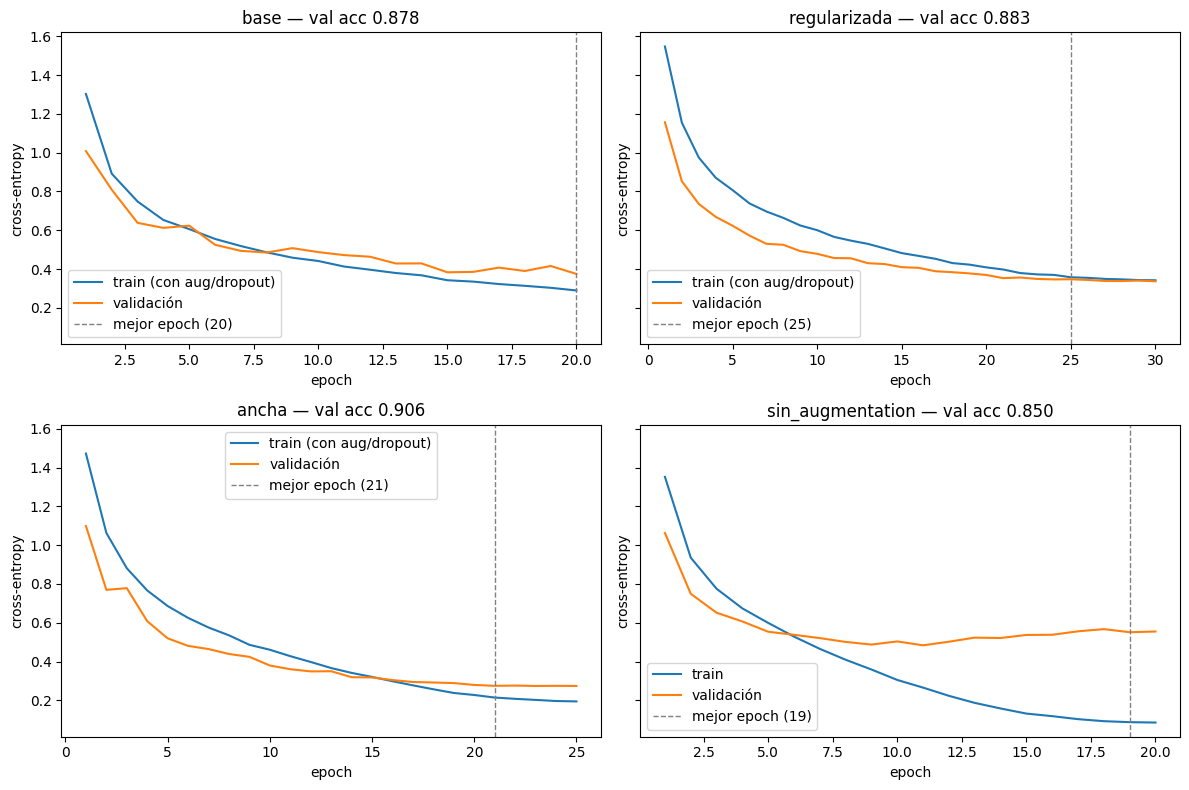

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, (name, r) in zip(axes.ravel(), RESULTS.items()):
    h = r["history"]; ep = range(1, len(h["train_loss"]) + 1)
    ax.plot(ep, h["train_loss"], label="train (con aug/dropout)" if r["config"]["augment"] else "train")
    ax.plot(ep, h["val_loss"], label="validación")
    ax.axvline(r["best_epoch"], color="gray", ls="--", lw=1, label=f"mejor epoch ({r['best_epoch']})")
    ax.set_title(f"{name} — val acc {r['val_best']['acc']:.3f}")
    ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy"); ax.legend()
plt.tight_layout(); plt.show()

### Accuracy de validación por epoch

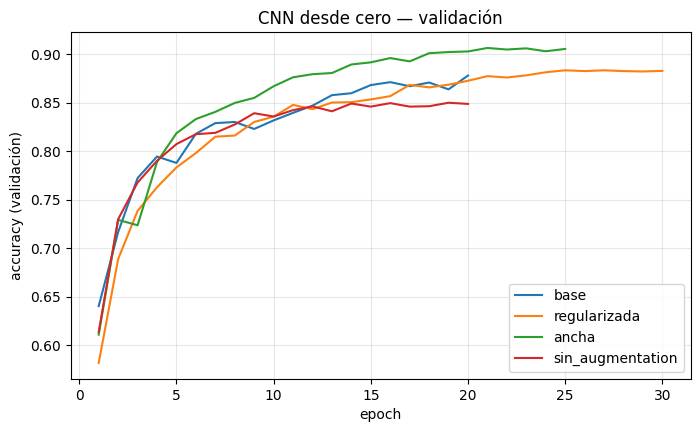

In [12]:
plt.figure(figsize=(8, 4.5))
for name, r in RESULTS.items():
    plt.plot(range(1, len(r["history"]["val_acc"]) + 1), r["history"]["val_acc"], label=name)
plt.xlabel("epoch"); plt.ylabel("accuracy (validación)"); plt.grid(alpha=0.3); plt.legend()
plt.title("CNN desde cero — validación"); plt.show()

## 5. Mejor configuración

In [13]:
best_name = max(RESULTS, key=lambda k: RESULTS[k]["val_best"]["f1"])
print("Mejor configuración (val F1 macro):", best_name)
print(df.loc[best_name, ["val acc", "val F1", "mejor epoch", "params totales", "tiempo total (s)"]])

with open("results_cnn.json", "w") as f:
    json.dump({"best": best_name, "results": RESULTS}, f, indent=2, default=lambda o: list(o) if isinstance(o, tuple) else str(o))

Mejor configuración (val F1 macro): ancha
val acc                 0.9062
val F1                0.905937
mejor epoch                 21
params totales         2198218
tiempo total (s)    847.096272
Name: ancha, dtype: object
